# Module 1. Samples

## Getting Started with Jupyter Notebooks

Jupyter Notebooks (or iPython Notebooks) are files with a mixture of Markdown and Python code. It's a very convenient format so we'll be using this quite a lot during this course!

### Google Colab

To get started, it is not necessary to install software on your laptop. [Google Colab](https://colab.research.google.com/) is a free online iPython development environment, but it does require a Google account in order to use it. You can create a local clone of the Github repo with the lab assignments and upload the Notebook files you want to work with to Colab.

Remark that the Google Colab environment has older versions installed of the Python libraries that we will be using throughout this course. Usually, that's not a problem, but sometimes you will run into errors, e.g. because some parameter in our Python code didn't exist yet in that version. The solution is to add a new code block at the beginning of your Notebook file with content:

In [1]:
%pip install --upgrade matplotlib
%pip install --upgrade scipy
%pip install --upgrade statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 35.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


You only have to do this in Notebooks where you encounter errors, and only for the libraries that cause these errors. The installation may take a while and you need to restart the Python runtime afterwards by clicking the button that appears.

### Local environment

If you prefer to have a local development environment, you need to install Python and Visual Studio Code with the necessary extensions for working with Python (e.g. Pylance, Jupyter, Jupyter Keymap, etc.) The first time you open a Notebook file, VSCode will offer you to install these extensions.

To install Python and VSCode on Windows, we recommend using `winget`. First, check the latest version of Python on the [Python website](https://www.python.org/downloads/windows/). For example, at the time of writing, the latest version was 3.12.2. We'll need to specify the major and minor version (e.g. 3.12) when installing. Then, open a PowerShell or command prompt as Administrator and run:

```console
> winget install Microsoft.VisualStudioCode
> winget install Python.Python.3.12
```

Remark that `winget upgrade --all` will install maintenance releases of Python, but it will not upgrade to a new major or minor version.

Most Python scripts (or Jupyter Notebooks) for analyzing data use the same program libraries. The most important ones are:

- `numpy` - multidimensional arrays, linear algebra, etc.
- `scipy` - mathematics, science, engineering etc.
- `pandas` - data-analysis and -manipulation
- `matplotlib`, `seaborn` - data visualisation
- `scikit-learn` - regression and machine learning

You can install these using `pip`:

```console
> pip install matplotlib numpy pandas scipy seaborn scikit-learn statsmodels
```

Or, alteratively, by executing the following code block:

In [2]:
%pip install matplotlib
%pip install numpy
%pip install pandas
%pip install scipy
%pip install seaborn
%pip install scikit-learn
%pip install statsmodels


Since you usually need the same packages every time, it is best to put them at the top of every script or Notebook file you write. By convention, package names are often abbreviated in a consistent manner, e.g. `np` for `numpy`, `sns` for `seaborn`, etc.

In [3]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Opening a Dataset, General Information

You can read in a dataset from a variety of sources (Rajagopalan, 2021, p.158). You can specify a path to a file or even a URL:

In [4]:
# Importing the Titanic dataset. (Rajagopalan, 2021, p. 106)
titanic = pd.read_csv('https://raw.githubusercontent.com/DataRepo2019/Data-files/master/titanic.csv')
# Show the first few records of the Data Frame
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


If you want to open a dataset that you stored on Google Drive (where Google Colab stores all your Notebooks), you can use the following code instead:

In [5]:
# Ensure your Google Drive is accessible from within the notebook
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset from your Google Drive (here, we stored it in a subfolder
# called "data")
titanic = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/titanic.csv')
titanic.head()

MessageError: Error: credential propagation was unsuccessful

Let's take a look at the properties of the dataset we just loaded:

In [6]:
# How many  rows does the DataFrame have?
print(f"Number of rows: {len(titanic)}")
# How many columns?
print(f"Number of columns: {len(titanic.columns)}")
# How many rows and columns, i.e. the shape
print(f"The shape of the Data Frame is: {titanic.shape}")
# General information about the DataFrame
print("*"*50)
titanic.info()

# Give the data type of each column.
print("*"*50)
print(titanic.dtypes)

# How many columns of each data type are there?
#   Watch it! The book says to use get_dtype_counts(), but this method no longer exists
print("*"*50)
print(titanic.dtypes.value_counts())

Number of rows: 891
Number of columns: 12
The shape of the Data Frame is: (891, 12)
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
**************************************************
PassengerId      int64
Survived         int64
Pclass      

## Indices

The columns "PassengerId" is not an actual variabele, but contains a number to identify each observation. You can mark this column as an index:

In [7]:
titanic.set_index(['PassengerId'])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


## Qualitative variables

Some of the variables, such as `Survived` and `Pclass`, are incorrectly considered to be quantitative. You can correct this by explicitly converting them to a **qualitative** (categorical) variable:

In [8]:
# Describe the variable Survived -> is considered to be quantitative
print(titanic.Survived.describe())
# Convert to a categorical variable
titanic.Survived = titanic.Survived.astype('category')
# Ask to describe once more -> now it is considered to be qualitative
print(titanic.Survived.describe())

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64
count     891
unique      2
top         0
freq      549
Name: Survived, dtype: int64


You can also mark variables as **ordinal**, that is, with an ordering. We will do this as an example with the variable "Embarked" and order the ports in the order of departure. The Titanic departed at SouthHampton, and then picked up passengers first at Cherbourg and then at Queenstown.

For cases like this, define your own datatype specifying the order:

In [9]:
print(titanic.Embarked.unique())

embarked_type = CategoricalDtype(categories=['S', 'C', 'Q'], ordered=True)
titanic.Embarked = titanic.Embarked.astype(embarked_type)
titanic.Embarked.describe()

['S' 'C' 'Q' nan]


,Embarked
count,889
unique,3
top,S
freq,644


This order will then always be respected, e.g. in graphs

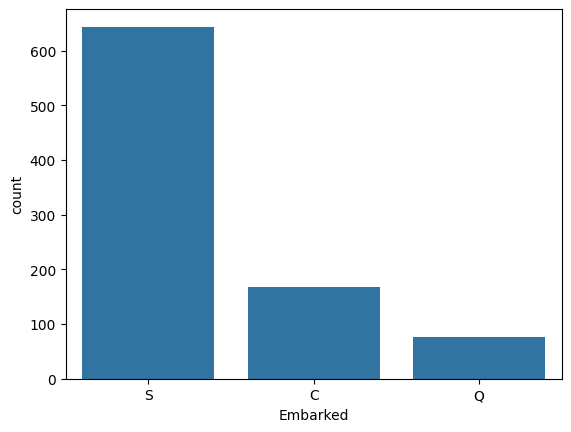

In [10]:
sns.countplot(data=titanic, x='Embarked');

## Selecting Data

In [11]:
# Select all observations for a single variable (i.e. a DataFrame column)
titanic.Age
# This also works (and is preferable as it will also work when the column name has a space in it):
# titanic['Age']
# This also works, but isn't very nice
# titanic.loc[:, 'Age']

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [12]:
# Select adjacent columns
titanic.iloc[:, 2:4]

,Pclass,Name
0,3,"Braund, Mr. Owen Harris"
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,"Heikkinen, Miss. Laina"
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,3,"Allen, Mr. William Henry"
...,...,...
886,2,"Montvila, Rev. Juozas"
887,1,"Graham, Miss. Margaret Edith"
888,3,"Johnston, Miss. Catherine Helen ""Carrie"""
889,1,"Behr, Mr. Karl Howell"


You can also select multiple columns based on their names.
This is often clearer than selecting based on position and the columns must
not be adjacent.

In [13]:
titanic[['Name', 'Age', 'Cabin']] # Note: two sets of square brackets!

,Name,Age,Cabin
0,"Braund, Mr. Owen Harris",22.0,NaN
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,C85
2,"Heikkinen, Miss. Laina",26.0,NaN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,C123
4,"Allen, Mr. William Henry",35.0,NaN
...,...,...,...
886,"Montvila, Rev. Juozas",27.0,NaN
887,"Graham, Miss. Margaret Edith",19.0,B42
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,NaN
889,"Behr, Mr. Karl Howell",26.0,C148


In [14]:
# Observation with row number 5 (counting from zero)
print(titanic.iloc[5])

# The first 4 observations
titanic.iloc[0:4]

PassengerId                   6
Survived                      0
Pclass                        3
Name           Moran, Mr. James
Sex                        male
Age                         NaN
SibSp                         0
Parch                         0
Ticket                   330877
Fare                     8.4583
Cabin                       NaN
Embarked                      Q
Name: 5, dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [15]:
# Select observations where the value of Age is less than 18
titanic[titanic.Age < 18]

# The same, but only keep the column 'Embarked'
titanic[titanic.Age < 18].Embarked

# The same, but keep columns 'Age' and 'Embarked'
titanic[titanic['Age'] < 18][['Age', 'Embarked']]

,Age,Embarked
7,2.0,S
9,14.0,C
10,4.0,S
14,14.0,S
16,2.0,Q
...,...,...
850,4.0,S
852,9.0,C
853,16.0,S
869,4.0,S


In [16]:
# Select all boys younger than 10
titanic.query("(Sex=='male') and (Age < 18)")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q
50,51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S
63,64,0,3,"Skoog, Master. Harald",male,4.00,3,2,347088,27.9000,NaN,S
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
86,87,0,3,"Ford, Mr. William Neal",male,16.00,1,3,W./C. 6608,34.3750,NaN,S
125,126,1,3,"Nicola-Yarred, Master. Elias",male,12.00,1,0,2651,11.2417,NaN,C
138,139,0,3,"Osen, Mr. Olaf Elon",male,16.00,0,0,7534,9.2167,NaN,S
163,164,0,3,"Calic, Mr. Jovo",male,17.00,0,0,315093,8.6625,NaN,S


## Dropping Data and Working with Missing Data

Pandas tries to make working with missing data as easy as possible. E.g., all of the descriptive statistics on pandas objects exclude missing data by default.

Let's starting by reading the titanic data again.

In [17]:
titanic = pd.read_csv('https://raw.githubusercontent.com/DataRepo2019/Data-files/master/titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The `PassengerId` column is identical to the index hence it doesn't provide any additional useful information. Let's drop this column (rather than setting it as the index as before). This can by done using `drop`.

In [18]:
titanic.drop("PassengerId", axis="columns")

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Notice that we actually didn't change the `titanic` `DataFrame`.  We can either assign the result of `drop` to a (new) `DataFrame`
or we can use `inplace=True`.

In [19]:
titanic.head(3) # PassengerId is still here

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [20]:
titanic = titanic.drop("PassengerId", axis="columns")
titanic.head(3) # PassengerId is now gone

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


From the output of the `info` method we can infer that certain columns contain many missing values, e.g. `Cabin` only contains 204 non-missing values.
For the purposes of illustration, let's drop any row that has a missing observation by using
the default behaviour of the `dropna` method.

In [21]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [22]:
cleaned = titanic.dropna() # Drop any row that has at least one missing value
print(cleaned.info())
cleaned.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  183 non-null    int64  
 1   Pclass    183 non-null    int64  
 2   Name      183 non-null    object 
 3   Sex       183 non-null    object 
 4   Age       183 non-null    float64
 5   SibSp     183 non-null    int64  
 6   Parch     183 non-null    int64  
 7   Ticket    183 non-null    object 
 8   Fare      183 non-null    float64
 9   Cabin     183 non-null    object 
 10  Embarked  183 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 17.2+ KB
None


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


This would only keep 183 values, which isn't a lot. We could also choose to drop only the rows that consist of nothing but missing values (there are no such rows in the `titanic` `DataFrame`), but here you can see how this would be done.

In [23]:
cleaned = titanic.dropna(how="all")
cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


Instead of relying on `info` to compute the number of non missing values we can also use the `isnull` and/or `notnull` methods.
`notnull` computes a boolean `DataFrame` where an entry is `True` if and only if that entry is considered to be non missing in the original `DataFrame`. We can then use `sum` the compute the sum of each column. This gives the number of non missing values per column.  

In [24]:
not_null_df = titanic.notnull()
print(not_null_df.tail(3))
print("Number of non null values in each column:")
print(not_null_df.sum())

     Survived  Pclass  Name   Sex    Age  SibSp  Parch  Ticket  Fare  Cabin  \
888      True    True  True  True  False   True   True    True  True  False   
889      True    True  True  True   True   True   True    True  True   True   
890      True    True  True  True   True   True   True    True  True  False   

     Embarked  
888      True  
889      True  
890      True  
Number of non null values in each column:
Survived    891
Pclass      891
Name        891
Sex         891
Age         714
SibSp       891
Parch       891
Ticket      891
Fare        891
Cabin       204
Embarked    889
dtype: int64


An even easier alternative is to simply use `count` on the `DataFrame`.

In [25]:
print(titanic.count())

Survived    891
Pclass      891
Name        891
Sex         891
Age         714
SibSp       891
Parch       891
Ticket      891
Fare        891
Cabin       204
Embarked    889
dtype: int64


The `Cabin` column has too many missing values, so probably isn't useful. For the `Age` column, we can *impute* the missing values, e.g. with the average age of all passengers. (We will see later what this means exactly). Let's do this using `fillna`.

In [26]:
# First compute the average age
avg_age = titanic['Age'].mean()
print(f"(Rounded) Average age of passengers: {round(avg_age)}")
titanic = titanic.fillna(value={'Age' : avg_age})
print("We should now confirm that the 'Age' column no longer has missing values")
titanic.info()

(Rounded) Average age of passengers: 30
We should now confirm that the 'Age' column no longer has missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


## Creating New Columns

We use a dataset containing $NO_2$ measurements in the the stations of Paris, Antwerp and London.

Let's read the data and check whether it worked.

In [27]:
URL = "https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_no2.csv"
air_quality = pd.read_csv(URL)
print(air_quality.info())
air_quality.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   datetime         1035 non-null   object 
 1   station_antwerp  95 non-null     float64
 2   station_paris    1004 non-null   float64
 3   station_london   969 non-null    float64
dtypes: float64(3), object(1)
memory usage: 32.5+ KB
None


,datetime,station_antwerp,station_paris,station_london
0,2019-05-07 02:00:00,NaN,NaN,23.0
1,2019-05-07 03:00:00,50.5,25.0,19.0
2,2019-05-07 04:00:00,45.0,27.7,19.0
3,2019-05-07 05:00:00,NaN,50.4,16.0
4,2019-05-07 06:00:00,NaN,61.9,NaN


We see that
- the dates are stored as strings (object)
- `datetime` is added as a column and we have a `RangeIndex`.

We would like to
- parse the dates, so that they are available as `datetime` objects
- index the `DataFrame` rows by this date.

This can be achieved by specifying the index column and by indicating that dates must be parsed on `read_csv`. Let's try again.

In [28]:
air_quality = pd.read_csv(URL, index_col=0, parse_dates=True)
print(air_quality.info())
air_quality.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1035 entries, 2019-05-07 02:00:00 to 2019-06-21 02:00:00
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   station_antwerp  95 non-null     float64
 1   station_paris    1004 non-null   float64
 2   station_london   969 non-null    float64
dtypes: float64(3)
memory usage: 32.3 KB
None


,station_antwerp,station_paris,station_london
datetime,,,
2019-05-07 02:00:00,NaN,NaN,23.0
2019-05-07 03:00:00,50.5,25.0,19.0
2019-05-07 04:00:00,45.0,27.7,19.0
2019-05-07 05:00:00,NaN,50.4,16.0
2019-05-07 06:00:00,NaN,61.9,NaN


We can clearly see the difference!

### Creating a New Column Derived from (an) Existing Column(s)

Assume we would like to express the concentration of the station in London in mg/m^3

*(If we assume temperature of 25 degrees Celsius and pressure of 1013 hPa, the conversion factor is 1.882)*

In [29]:
air_quality["london_mg_per_cubic"] = air_quality["station_london"] * 1.882
air_quality.head()

,station_antwerp,station_paris,station_london,london_mg_per_cubic
datetime,,,,
2019-05-07 02:00:00,NaN,NaN,23.0,43.286
2019-05-07 03:00:00,50.5,25.0,19.0,35.758
2019-05-07 04:00:00,45.0,27.7,19.0,35.758
2019-05-07 05:00:00,NaN,50.4,16.0,30.112
2019-05-07 06:00:00,NaN,61.9,NaN,NaN


To create a new column, use the `[]` brackets with the new column name at the left side of the assignment.  The computation is done **element wise**, hence there is no need for an explict loop!

We can also use multiple columns to derive a new column.

Let's check the ratio of the values in Paris versus Antwerp and save the result in a new column.

In [30]:
air_quality["ratio_paris_antwerp"] = air_quality["station_paris"] / air_quality["station_antwerp"]
air_quality.head()

,station_antwerp,station_paris,station_london,london_mg_per_cubic,ratio_paris_antwerp
datetime,,,,,
2019-05-07 02:00:00,NaN,NaN,23.0,43.286,NaN
2019-05-07 03:00:00,50.5,25.0,19.0,35.758,0.495050
2019-05-07 04:00:00,45.0,27.7,19.0,35.758,0.615556
2019-05-07 05:00:00,NaN,50.4,16.0,30.112,NaN
2019-05-07 06:00:00,NaN,61.9,NaN,NaN,NaN


We can also perform more general mappings on columns, either using a function or a dictionary.

Let's work with the Titanic data once more.  Let's say we want to numerically encode the `Sex` column, this can be done as follows. First let's check the unique values in the `Sex` column.

In [31]:
titanic['Sex'].unique()

array(['male', 'female'], dtype=object)

In [32]:
mapping_dict = {'male' : 0, 'female' : 1}
titanic['Sex'] = titanic['Sex'].map(mapping_dict)

Let's check whether it worked.

In [33]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


Let's add a new feature (i.e. a new column). When `Age` is less than 12 we will call this passenger a `child`,
between 12 and 18 a `teen` and over 18 will be `adult`s.  First, we define a Python function implementing
this mapping, and then we apply it to the `Age` column.

In [34]:
def age_to_category(age):
    if age < 12:
        return "child"
    if age < 18:
        return "teen"
    return "adult"

titanic['AgeCategory'] = titanic['Age'].map(age_to_category)
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeCategory
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,adult
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,adult
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,adult
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,adult
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,adult


Here, we only scratched the surface of what is possible with pandas (and indeed, whole books have been written about pandas). In general the pandas getting started guide, the user guide and the API reference are very good resources to find additional information. You can find
all of these [here](https://pandas.pydata.org/pandas-docs/stable/index.html).